In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier
)

from xgboost import XGBRegressor

import shap
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv(
    "../data/processed/insurance_clean.csv"
)

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate,LossRatio
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10,0.000000
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13,4.234362
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17,0.000000
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17,5.119831
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10,0.000000


In [4]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Province', 'VehicleType',
       'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD',
       'PastClaims', 'Claimed', 'ClaimAmount', 'TotalPremium', 'TotalClaims',
       'CoverType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate',
       'ZipCode', 'TransactionDate', 'LossRatio'],
      dtype='str')

In [8]:
df["TransactionDate"] = pd.to_datetime(
    df["TransactionDate"]
)

In [9]:
df["TransactionYear"] = (
    df["TransactionDate"].dt.year
)


df["TransactionMonth"] = (
    df["TransactionDate"].dt.month
)

In [10]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,25,40,60,100],
    labels=[
        "Young",
        "Adult",
        "MiddleAge",
        "Senior"
    ]
)

In [11]:
df["ClaimFrequency"] = (
    df["Claimed"]
)

In [12]:
df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate,LossRatio,TransactionYear,TransactionMonth,AgeGroup,ClaimFrequency
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,Lifan,620,32238,10002,2024-05-10,0.000000,2024,5,MiddleAge,False
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,Suzuki,Grand Vitara,52510,10001,2024-08-13,4.234362,2024,8,Senior,True
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,Lifan,620,26523,20001,2025-03-17,0.000000,2025,3,MiddleAge,False
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,Toyota,Corolla,27036,40005,2025-03-17,5.119831,2025,3,Adult,True
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,Toyota,RAV4,58348,50002,2024-11-10,0.000000,2024,11,MiddleAge,False


In [13]:
drop_columns = [
    "CustomerID",
    "TransactionDate"
]


df = df.drop(
    columns=[
        c for c in drop_columns
        if c in df.columns
    ]
)

In [14]:
numeric_cols = df.select_dtypes(
    include=["int64","float64"]
).columns


for col in numeric_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

In [15]:
categorical_cols = df.select_dtypes(
    include="object"
).columns


for col in categorical_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

/tmp/ipykernel_93945/1869615201.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


In [16]:
df.select_dtypes(
    include=["object","category"]
).columns

/tmp/ipykernel_93945/1286912610.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(


Index(['Gender', 'Province', 'VehicleType', 'CoverType', 'AutoMake',
       'VehicleModel', 'AgeGroup'],
      dtype='str')

In [17]:
categorical_features = [
    "Gender",
    "Province",
    "VehicleType",
    "CoverType",
    "AutoMake",
    "VehicleModel",
    "AgeGroup"
]

In [18]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True
)

In [19]:
df_encoded.head()

,Age,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,Claimed,ClaimAmount,TotalPremium,...,VehicleModel_Grand Vitara,VehicleModel_Land Cruiser,VehicleModel_RAV4,VehicleModel_Swift,VehicleModel_Tucson,VehicleModel_Vitz,VehicleModel_i10,AgeGroup_Adult,AgeGroup_MiddleAge,AgeGroup_Senior
0,56,147270,61,2346,500,30,1,False,0.0,2346,...,False,False,False,False,False,False,False,False,True,False
1,69,74640,57,2334,500,0,4,True,9883.0,2334,...,True,False,False,False,False,False,False,False,False,True
2,46,70555,42,1697,250,20,1,False,0.0,1697,...,False,False,False,False,False,False,False,False,True,False
3,32,89398,63,2370,500,20,0,True,12134.0,2370,...,False,False,False,False,False,False,False,True,False,False
4,60,78475,69,2582,500,0,4,False,0.0,2582,...,False,False,True,False,False,False,False,False,True,False


In [20]:
severity = df_encoded[
    df_encoded["TotalClaims"] > 0
]

In [21]:
y = severity["TotalClaims"]

In [22]:
X = severity.drop(
    "TotalClaims",
    axis=1
)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
lr = LinearRegression()


lr.fit(
    X_train,
    y_train
)


pred_lr = lr.predict(
    X_test
)

In [25]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)


rf.fit(
    X_train,
    y_train
)


pred_rf = rf.predict(
    X_test
)

In [26]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)


xgb.fit(
    X_train,
    y_train
)


pred_xgb = xgb.predict(
    X_test
)

In [27]:
def evaluate_model(
    name,
    y_test,
    prediction
):

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )

    r2 = r2_score(
        y_test,
        prediction
    )

    return {
        "Model": name,
        "RMSE": rmse,
        "R2": r2
    }

In [28]:
results = []


results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        pred_lr
    )
)


results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        pred_rf
    )
)


results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        pred_xgb
    )
)


results_df = pd.DataFrame(results)

results_df

,Model,RMSE,R2
0,Linear Regression,4.053869e-12,1.000000
1,Random Forest,1.409615e+02,0.999438
2,XGBoost,2.436226e+02,0.998322


In [29]:
results_df.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

In [30]:
explainer = shap.TreeExplainer(
    xgb
)


shap_values = explainer.shap_values(
    X_test
)

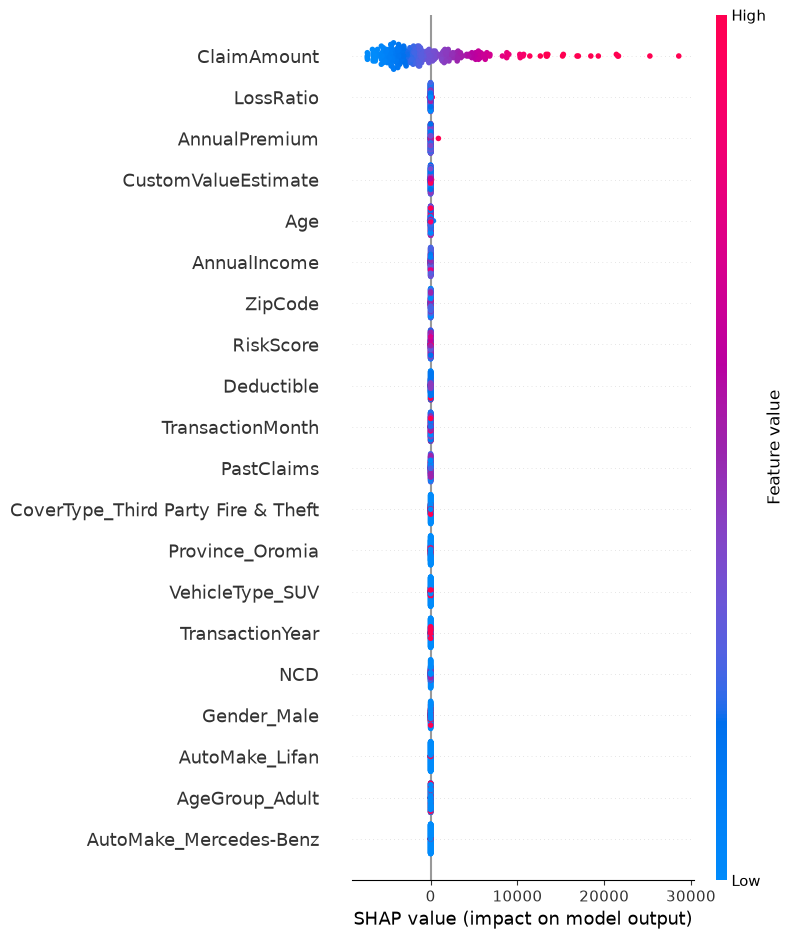

In [31]:
shap.summary_plot(
    shap_values,
    X_test
)

In [32]:
plt.savefig(
    "../reports/shap_summary.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [33]:
df_encoded["HasClaim"] = (
    df_encoded["TotalClaims"] > 0
).astype(int)

In [34]:
X_class = df_encoded.drop(
    [
        "TotalClaims",
        "HasClaim"
    ],
    axis=1
)


y_class = df_encoded["HasClaim"]

In [35]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

In [36]:
classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)


classifier.fit(
    X_train_c,
    y_train_c
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [37]:
df_encoded["ClaimProbability"] = classifier.predict_proba(
    X_class
)[:,1]

In [38]:
df_encoded["PredictedSeverity"] = xgb.predict(
    X_class
)

In [39]:
expense_loading = 100

profit_margin = 200


df_encoded["RecommendedPremium"] = (

    df_encoded["ClaimProbability"]

    *

    df_encoded["PredictedSeverity"]

    +

    expense_loading

    +

    profit_margin

)

In [40]:
df_encoded[
[
"ClaimProbability",
"PredictedSeverity",
"RecommendedPremium"
]
].head()

,ClaimProbability,PredictedSeverity,RecommendedPremium
0,0.000,1187.275513,300.000000
1,0.995,9889.149414,10139.703667
2,0.000,1293.658691,300.000000
3,1.000,12117.241211,12417.241211
4,0.000,1179.888916,300.000000
